# Análisis TIR y VAN
Carga de librerías y definición de parámetros, escenarios y matrices de resultados.

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# 1. Preparación de Datos
tipologias = ["Unifam seg", "Unifam conj", "Plurifam U2C", "Plurifam U4C"]
escenarios = ["Conservador", "Base", "Optimista"]

# Colores institucionales para análisis financiero
azules = ["#c6dbef", "#6baed6", "#2171b5"] # Venta
rojos  = ["#fcbba1", "#fb6a4a", "#cb181d"] # Alquiler

tir_venta = np.array([
    [0.1281, 0.2126, 0.3160],
    [0.1188, 0.1985, 0.2975],
    [0.1543, 0.2266, 0.3109],
    [0.1065, 0.1588, 0.2221]
])

tir_alquiler = np.array([
    [-0.0256, -0.0009, 0.0241],
    [-0.0234, 0.0015, 0.0267],
    [0.0239, 0.0498, 0.0751],
    [0.0208, 0.0470, 0.0727]
])

van_venta = np.array([
    [0.21, 0.64, 0.99],
    [0.18, 0.72, 1.16],
    [0.79, 1.44, 1.97],
    [0.16, 1.14, 1.94]
])

van_alquiler = np.array([
    [-5.03, -4.51, -3.83],
    [-5.99, -5.34, -4.48],
    [-3.91, -2.90, -1.65],
    [-5.65, -4.26, -2.51]
])



## TIR por escenarios
Comparativa de TIR para venta y alquiler por tipología, diferenciando escenarios.

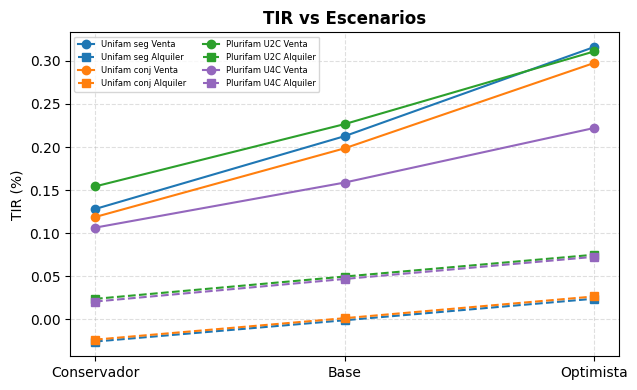

In [56]:
# TIR vs Escenarios
fig, ax1 = plt.subplots(figsize=(6.5, 4))

esc_x = ["Conservador", "Base", "Optimista"]
x = np.arange(len(esc_x))
colores_tip = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

for i, t in enumerate(tipologias):
    ax1.plot(x, tir_venta[i, :], marker='o', linestyle='-',
             color=colores_tip[i], label=f"{t} Venta")
    ax1.plot(x, tir_alquiler[i, :], marker='s', linestyle='--',
             color=colores_tip[i], label=f"{t} Alquiler")

ax1.set_title("TIR vs Escenarios", fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(esc_x)
ax1.set_ylabel("TIR (%)")
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

## Eficiencia TIR vs VAN
Relación TIR-VAN para todos los escenarios, con doble leyenda por color y marcador.

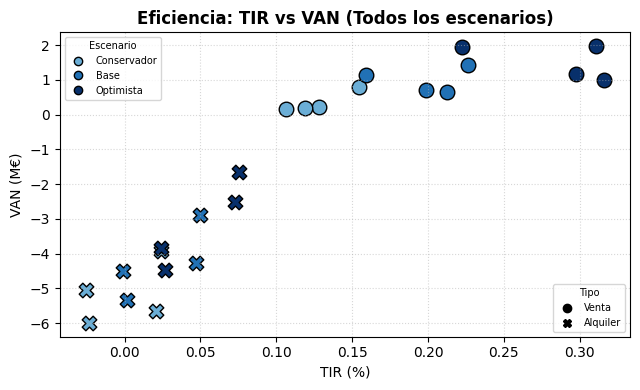

In [57]:
# Eficiencia: TIR vs VAN (Todos los escenarios)
fig, ax2 = plt.subplots(figsize=(6.5, 4))

colores_esc = ["#6baed6", "#2171b5", "#08306b"]
markers = {"Venta": "o", "Alquiler": "X"}

for j, esc in enumerate(escenarios):
    ax2.scatter(tir_venta[:, j], van_venta[:, j],
                s=110, marker=markers["Venta"], color=colores_esc[j],
                edgecolors='k')
    ax2.scatter(tir_alquiler[:, j], van_alquiler[:, j],
                s=110, marker=markers["Alquiler"], color=colores_esc[j],
                edgecolors='k')

ax2.set_title("Eficiencia: TIR vs VAN (Todos los escenarios)", fontweight='bold')
ax2.set_xlabel("TIR (%)")
ax2.set_ylabel("VAN (M€)")
ax2.grid(True, linestyle=':', alpha=0.5)

legend_esc = ax2.legend(
    handles=[Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                    markeredgecolor='k', markersize=6, linestyle='')
             for c in colores_esc],
    labels=escenarios, title="Escenario", fontsize=7, title_fontsize=7,
    loc='upper left'
 )
ax2.add_artist(legend_esc)

ax2.legend(
    handles=[
        Line2D([0], [0], marker='o', color='black', linestyle='', label='Venta'),
        Line2D([0], [0], marker='X', color='black', linestyle='', label='Alquiler')
    ],
    title="Tipo", fontsize=7, title_fontsize=7, loc='lower right'
)

plt.tight_layout()
plt.show()

## VAN por tipología
Comparación de VAN de venta y alquiler en subplots con el mismo ancho.

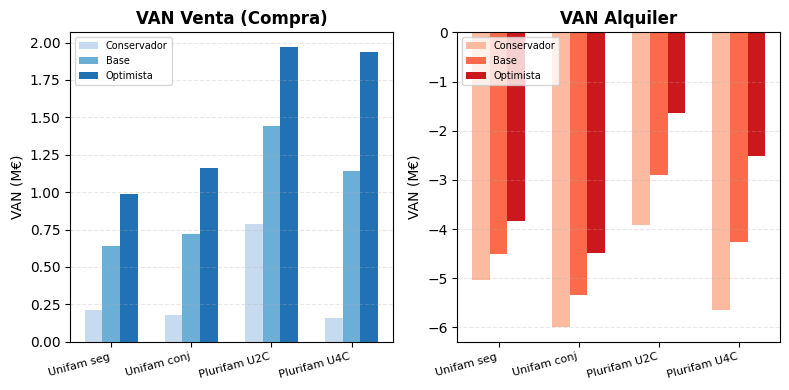

In [63]:
# VAN: Venta y Alquiler (1:1)
fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1])
ax3 = fig.add_subplot(gs[0, 0])
ax4 = fig.add_subplot(gs[0, 1])

x_tip = np.arange(len(tipologias))
width = 0.22

for i in range(3):
    ax3.bar(x_tip + i * width, van_venta[:, i],
            width, label=escenarios[i], color=azules[i])

ax3.set_title("VAN Venta (Compra)", fontweight='bold')
ax3.set_xticks(x_tip + width)
ax3.set_xticklabels(tipologias, rotation=15, ha='right', fontsize=8)
ax3.set_ylabel("VAN (M€)")
ax3.grid(axis='y', linestyle='--', alpha=0.3)
ax3.legend(fontsize=7, loc='upper left')

for i in range(3):
    ax4.bar(x_tip + i * width, van_alquiler[:, i],
            width, label=escenarios[i], color=rojos[i])

ax4.set_title("VAN Alquiler", fontweight='bold')
ax4.set_xticks(x_tip + width)
ax4.set_xticklabels(tipologias, rotation=15, ha='right', fontsize=8)
ax4.set_ylabel("VAN (M€)")
ax4.grid(axis='y', linestyle='--', alpha=0.3)
ax4.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

## Ranking de creación de valor
Ranking por VAN (escenario base) con etiquetas fuera de las barras.

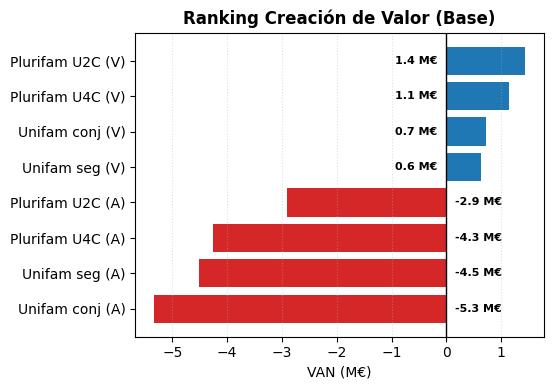

In [59]:
# Ranking Creación de Valor (Base)
fig, ax5 = plt.subplots(figsize=(7, 4))

total_van = np.concatenate([van_venta[:, 1], van_alquiler[:, 1]])
labels = [f"{t} (V)" for t in tipologias] + [f"{t} (A)" for t in tipologias]

idx = np.argsort(total_van)
vals = total_van[idx]
labs = np.array(labels)[idx]

colors = ["#1f77b4" if v > 0 else "#d62728" for v in vals]
bars = ax5.barh(labs, vals, color=colors)

ax5.axvline(0, color='black', linewidth=1)
ax5.set_title("Ranking Creación de Valor (Base)", fontweight='bold')
ax5.set_xlabel("VAN (M€)")
ax5.grid(axis='x', linestyle=':', alpha=0.4)

max_abs = np.max(np.abs(vals))
gap = max_abs * 0.03

for bar in bars:
    w = bar.get_width()
    x_text = -gap if w > 0 else gap
    ha = 'right' if w > 0 else 'left'
    ax5.text(x_text, bar.get_y() + bar.get_height()/2,
             f"{w:.1f} M€",
             ha=ha, va='center', color='black', fontsize=8, fontweight='bold')

plt.tight_layout()

# Ajuste final: ranking más estrecho y alineado a la derecha
pos = ax5.get_position()
new_width = pos.width * 0.75
new_x0 = pos.x0 + (pos.width - new_width)
ax5.set_position([new_x0, pos.y0, new_width, pos.height])

plt.show()